In [ ]:
import os
import time
import copy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

warnings.filterwarnings("ignore")

LOG_DIR = "logs/d02"
os.makedirs(LOG_DIR, exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Log dir: {os.path.abspath(LOG_DIR)}")

Device: cuda
Log dir: /home/user/projects/Quantization-and-Pruning/pruning/logs/d02


In [3]:
class LeNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.bn1   = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.bn2   = nn.BatchNorm2d(16)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2)
        x = F.max_pool2d(F.relu(self.bn2(self.conv2(x))), 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = datasets.MNIST("./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64,  shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Train: 60000 | Test: 10000


In [5]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = F.cross_entropy(out, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.size(0)
        correct += out.argmax(1).eq(target).sum().item()
        total += data.size(0)
    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        out = model(data)
        loss = F.cross_entropy(out, target, reduction="sum")
        total_loss += loss.item()
        correct += out.argmax(1).eq(target).sum().item()
        total += data.size(0)
    return 100.0 * correct / total, total_loss / total


@torch.no_grad()
def measure_inference_ms(model, loader, device, n_batches=30, warmup=10):
    model.eval()
    for i, (data, _) in enumerate(loader):
        if i >= warmup:
            break
        _ = model(data.to(device))
    if device.type == "cuda":
        torch.cuda.synchronize()

    times = []
    for i, (data, _) in enumerate(loader):
        if i >= n_batches:
            break
        data = data.to(device)
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = model(data)
        if device.type == "cuda":
            torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000.0)
    return float(np.mean(times)) if times else float("nan")


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_size_mb(model):
    return count_params(model) * 4 / (1024 ** 2)

In [6]:
NUM_EPOCHS = 3
LR = 1e-3

base_model = LeNet().to(device)
optimizer  = torch.optim.Adam(base_model.parameters(), lr=LR)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(base_model, train_loader, optimizer, device)
    te_acc, te_loss = evaluate(base_model, test_loader, device)
    print(f"Epoch {epoch}: train_loss={tr_loss:.4f} train_acc={tr_acc:.2f}%  "
          f"test_loss={te_loss:.4f} test_acc={te_acc:.2f}%")

base_state = copy.deepcopy(base_model.state_dict())

base_acc, _  = evaluate(base_model, test_loader, device)
base_time    = measure_inference_ms(base_model, test_loader, device)
base_params  = count_params(base_model)
base_size    = model_size_mb(base_model)

print(f"\nBaseline: acc={base_acc:.2f}%  params={base_params:,}  "
      f"size={base_size:.4f} MB  inf={base_time:.3f} ms")

pd.DataFrame([{
    "strategy": "baseline", "ratio": 0.0,
    "accuracy": base_acc, "loss": np.nan,
    "params": base_params, "size_mb": base_size,
    "inference_ms": base_time, "prune_time_s": 0.0,
}]).to_csv(os.path.join(LOG_DIR, "baseline.csv"), index=False)

Epoch 1: train_loss=0.1949 train_acc=94.20%  test_loss=0.0780 test_acc=97.50%
Epoch 2: train_loss=0.0627 train_acc=98.05%  test_loss=0.0448 test_acc=98.47%
Epoch 3: train_loss=0.0474 train_acc=98.53%  test_loss=0.0613 test_acc=98.09%

Baseline: acc=98.09%  params=44,470  size=0.1696 MB  inf=0.673 ms


In [7]:
example_inputs = torch.randn(1, 1, 28, 28, device=device)

In [20]:
import torch_pruning as tp
print([name for name in dir(tp.importance) if 'Importance' in name])

['ActivationImportance', 'BNScaleImportance', 'FPGMImportance', 'GroupHessianImportance', 'GroupMagnitudeImportance', 'GroupTaylorImportance', 'HessianImportance', 'Importance', 'LAMPImportance', 'MagnitudeImportance', 'OBDCImportance', 'RandomImportance', 'TaylorImportance']


In [17]:
def prune_structured(model, ratio, method="magnitude"):
    ignored_layers = [model.fc3]

    if method == "magnitude":
        imp = tp.importance.MagnitudeImportance(p=2)
        pruner = tp.pruner.MagnitudePruner(
            model, example_inputs, importance=imp,
            global_pruning=True, pruning_ratio=ratio,
            ignored_layers=ignored_layers,
        )
    elif method == "bn":
        imp = tp.importance.BNScaleImportance()
        pruner = tp.pruner.BNScalePruner(
            model, example_inputs, importance=imp,
            global_pruning=True, pruning_ratio=ratio,
            ignored_layers=ignored_layers,
        )
    elif method == "groupnorm":
        imp = tp.importance.GroupMagnitudeImportance(p=2)
        pruner = tp.pruner.GroupNormPruner(
            model, example_inputs, importance=imp,
            global_pruning=True, pruning_ratio=ratio,
            ignored_layers=ignored_layers,
        )
    elif method == "fpgm":
        imp = tp.importance.FPGMImportance(p=2)
        pruner = tp.pruner.MagnitudePruner(
            model, example_inputs, importance=imp,
            global_pruning=True, pruning_ratio=ratio,
            ignored_layers=ignored_layers,
        )
    elif method == "lamp":
        imp = tp.importance.LAMPImportance(p=2)
        pruner = tp.pruner.MagnitudePruner(
            model, example_inputs, importance=imp,
            global_pruning=True, pruning_ratio=ratio,
            ignored_layers=ignored_layers,
        )
    elif method == "random":
        imp = tp.importance.RandomImportance()
        pruner = tp.pruner.MagnitudePruner(
            model, example_inputs, importance=imp,
            global_pruning=True, pruning_ratio=ratio,
            ignored_layers=ignored_layers,
        )
    else:
        raise ValueError(f"Unknown method: {method}")

    pruner.step()
    return model


STRATEGIES = {
    "structured_magnitude": lambda m, r: prune_structured(m, r, "magnitude"),
    "structured_bn":        lambda m, r: prune_structured(m, r, "bn"),
    "structured_groupnorm": lambda m, r: prune_structured(m, r, "groupnorm"),
    "structured_fpgm":      lambda m, r: prune_structured(m, r, "fpgm"),
    "structured_lamp":      lambda m, r: prune_structured(m, r, "lamp"),
    "structured_random":    lambda m, r: prune_structured(m, r, "random"),
}
print(f"Strategies: {list(STRATEGIES.keys())}")

Strategies: ['structured_magnitude', 'structured_bn', 'structured_groupnorm', 'structured_fpgm', 'structured_lamp', 'structured_random']


In [18]:
PRUNING_RATIOS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

In [23]:
all_rows = []

for strategy_name, prune_fn in STRATEGIES.items():
    print(f"\n=== {strategy_name} ===")
    for ratio in PRUNING_RATIOS:
        model = LeNet().to(device)
        model.load_state_dict(copy.deepcopy(base_state))

        t0 = time.perf_counter()
        try:
            model = prune_fn(model, ratio)
            ok, err = True, ""
        except Exception as e:
            ok, err = False, f"{type(e).__name__}: {e}"
        prune_time = time.perf_counter() - t0

        if ok:
            acc, loss = evaluate(model, test_loader, device)
            inf_ms    = measure_inference_ms(model, test_loader, device)
            n_params  = count_params(model)
            size_mb   = model_size_mb(model)
        else:
            acc = loss = inf_ms = n_params = size_mb = np.nan

        all_rows.append({
            "strategy":     strategy_name,
            "ratio":        ratio,
            "accuracy":     acc,
            "loss":         loss,
            "params":       n_params,
            "size_mb":      size_mb,
            "inference_ms": inf_ms,
            "prune_time_s": prune_time,
            "error":        err,
        })

        if ok:
            status = (f"acc={acc:.2f}%  params={n_params:,}  "
                      f"size={size_mb:.3f}MB  inf={inf_ms:.3f}ms")
        else:
            status = f"FAILED ({err})"
        print(f"  ratio={ratio:.2f}  {status}")

df_all = pd.DataFrame(all_rows)
out_csv = os.path.join(LOG_DIR, "all_strategies_structured.csv")
df_all.to_csv(out_csv, index=False)
print(f"\n✓ Saved: {os.path.abspath(out_csv)}")
print(f"  Rows: {len(df_all)}  |  Strategies: {df_all['strategy'].nunique()}")
print(df_all.groupby("strategy")["ratio"].count().to_string())


=== structured_magnitude ===
  ratio=0.00  acc=98.09%  params=44,470  size=0.170MB  inf=1.925ms
  ratio=0.10  acc=98.09%  params=37,989  size=0.145MB  inf=1.867ms
  ratio=0.20  acc=44.89%  params=28,448  size=0.109MB  inf=1.731ms
  ratio=0.30  acc=62.94%  params=21,594  size=0.082MB  inf=1.783ms
  ratio=0.40  acc=59.70%  params=15,299  size=0.058MB  inf=1.459ms
  ratio=0.50  acc=53.92%  params=11,283  size=0.043MB  inf=1.318ms
  ratio=0.60  acc=46.29%  params=6,999  size=0.027MB  inf=1.576ms
  ratio=0.70  acc=22.30%  params=3,712  size=0.014MB  inf=1.268ms

=== structured_bn ===
  ratio=0.00  acc=98.09%  params=44,470  size=0.170MB  inf=2.281ms
  ratio=0.10  acc=75.95%  params=41,591  size=0.159MB  inf=1.759ms
  ratio=0.20  acc=77.85%  params=37,545  size=0.143MB  inf=1.531ms
  ratio=0.30  acc=53.46%  params=35,194  size=0.134MB  inf=1.638ms
  ratio=0.40  acc=63.58%  params=32,893  size=0.125MB  inf=1.727ms
  ratio=0.50  acc=57.55%  params=28,947  size=0.110MB  inf=1.518ms
  ratio=0.6

Loaded 48 rows | 6 strategies
strategy
structured_bn           8
structured_fpgm         8
structured_groupnorm    8
structured_lamp         8
structured_magnitude    8
structured_random       8


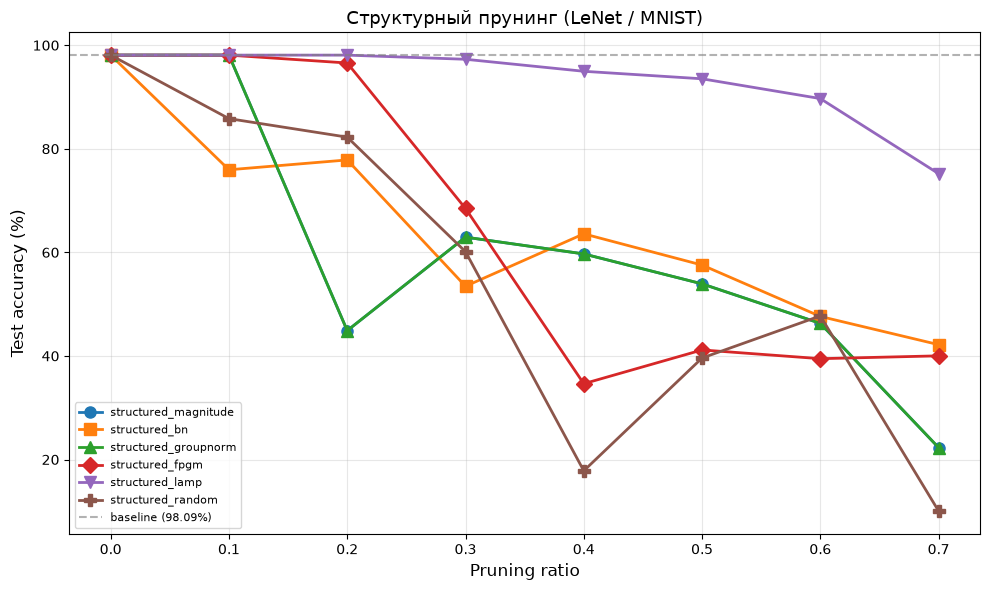

Saved: logs/d02/accuracy_structured_strategies.png


In [27]:
df_all   = pd.read_csv(os.path.join(LOG_DIR, "all_strategies_structured.csv"))
baseline = pd.read_csv(os.path.join(LOG_DIR, "baseline.csv")).iloc[0]

df_plot   = df_all.dropna(subset=["accuracy"]).copy()
strategies = list(df_plot["strategy"].unique())

print(f"Loaded {len(df_all)} rows | {len(strategies)} strategies")
print(df_all.groupby("strategy")["ratio"].count().to_string())

cmap    = plt.cm.tab10
colors  = [cmap(i) for i in range(len(strategies))]
markers = ["o", "s", "^", "D", "v", "P", "*", "X", "<", ">"][: len(strategies)]

fig, ax = plt.subplots(figsize=(10, 6))
for i, s in enumerate(strategies):
    sub = df_plot[df_plot["strategy"] == s].sort_values("ratio")
    ax.plot(sub["ratio"], sub["accuracy"],
            marker=markers[i], color=colors[i], label=s,
            linewidth=2, markersize=8)

ax.axhline(y=baseline["accuracy"], color="gray", ls="--", alpha=0.6,
           label=f"baseline ({baseline['accuracy']:.2f}%)")

ax.set_xlabel("Pruning ratio", fontsize=12)
ax.set_ylabel("Test accuracy (%)", fontsize=12)
ax.set_title("Структурный прунинг (LeNet / MNIST)", fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
out_path = os.path.join(LOG_DIR, "accuracy_structured_strategies.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

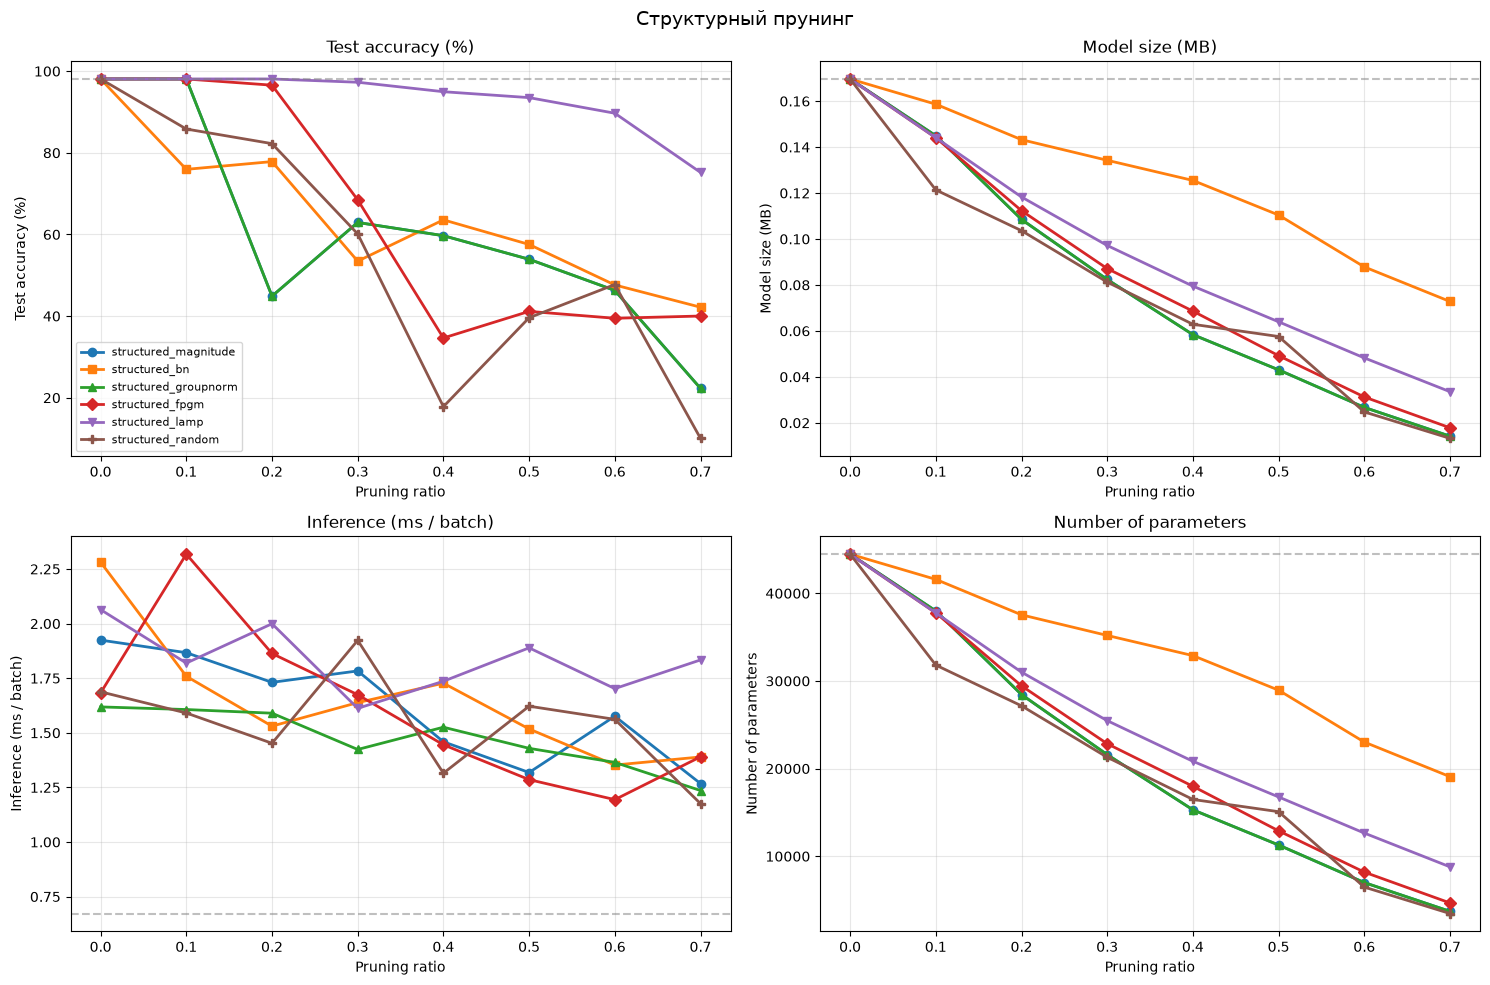

Saved: logs/d02/dashboard_structured_strategies.png


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metrics = [
    ("accuracy",     "Test accuracy (%)"),
    ("size_mb",      "Model size (MB)"),
    ("inference_ms", "Inference (ms / batch)"),
    ("params",       "Number of parameters"),
]
for ax, (col, ylabel) in zip(axes.flat, metrics):
    for i, s in enumerate(strategies):
        sub = df_plot[df_plot["strategy"] == s].sort_values("ratio")
        ax.plot(sub["ratio"], sub[col],
                marker=markers[i], color=colors[i], label=s,
                linewidth=2, markersize=6)
    if col in baseline:
        ax.axhline(y=baseline[col], color="gray", ls="--", alpha=0.5)
    ax.set_xlabel("Pruning ratio")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.grid(True, alpha=0.3)

axes[0, 0].legend(fontsize=8)
plt.suptitle("Структурный прунинг", fontsize=14)
plt.tight_layout()
out_path = os.path.join(LOG_DIR, "dashboard_structured_strategies.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")